In [1]:
import numpy as np
import qstudy as qs
from qstudy.constants import SP500
import matplotlib.pyplot as plt

## Data

In [2]:
start_date = "2015-01-01"
end_date = "2023-12-31"
universe = qs.download(SP500, start_date, end_date)
factors = qs.download(["SPY", "XLK"], start_date, end_date)

$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['SOLV', 'GEV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


In [11]:
returns_df = universe['returns']
close_df = universe['close']
volume_df = universe['volume']
factor_returns = factors['returns']

## Residualize Returns

In [12]:
residuals_df, factor_params, factor_rsq = qs.residualize(returns_df, factor_returns)

## Baseline: Residual Mean Reversion

sharpe                     0.881315
ann_return                 0.212196
ann_vol                    0.255590
max_drawdown              -0.478900
max_drawdown_duration    217.000000
avg_daily_turnover         0.777049
dtype: float64


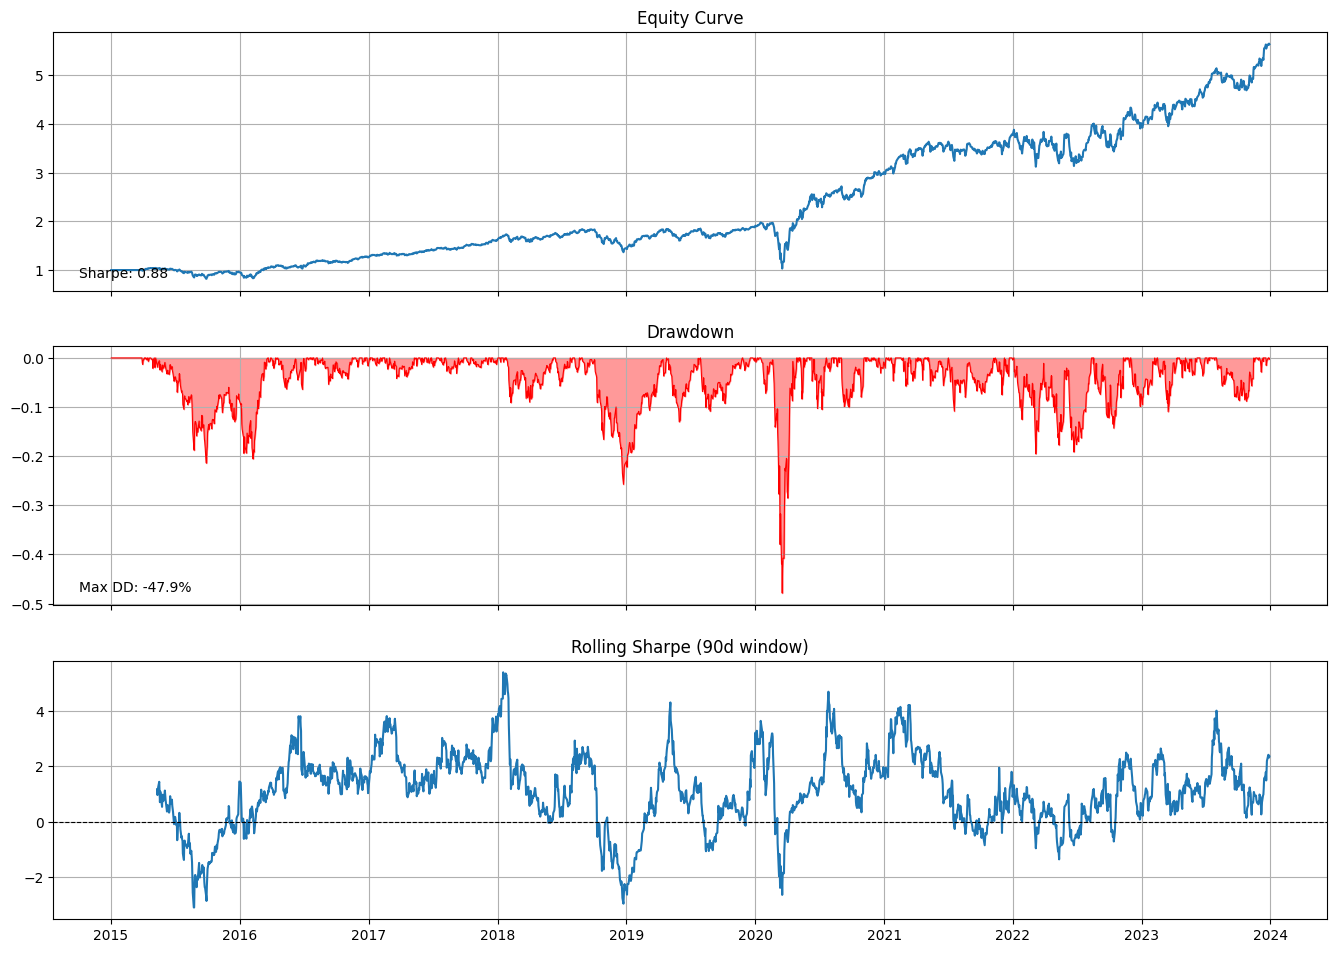

In [13]:
signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

positions = qs.build_positions(signal, n_long=25, n_short=25)
port_ret = qs.run(positions, ret_filtered)

print(qs.metrics.summary(port_ret, positions))
ax = qs.summary_plot(port_ret)

## Grid Search: Volume Filter

param_grid: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:23<00:00,  5.73it/s]


<Axes: title={'center': 'Volume Filter — Sharpe by (quantile, vol window)'}, xlabel='vol_wind', ylabel='qt'>

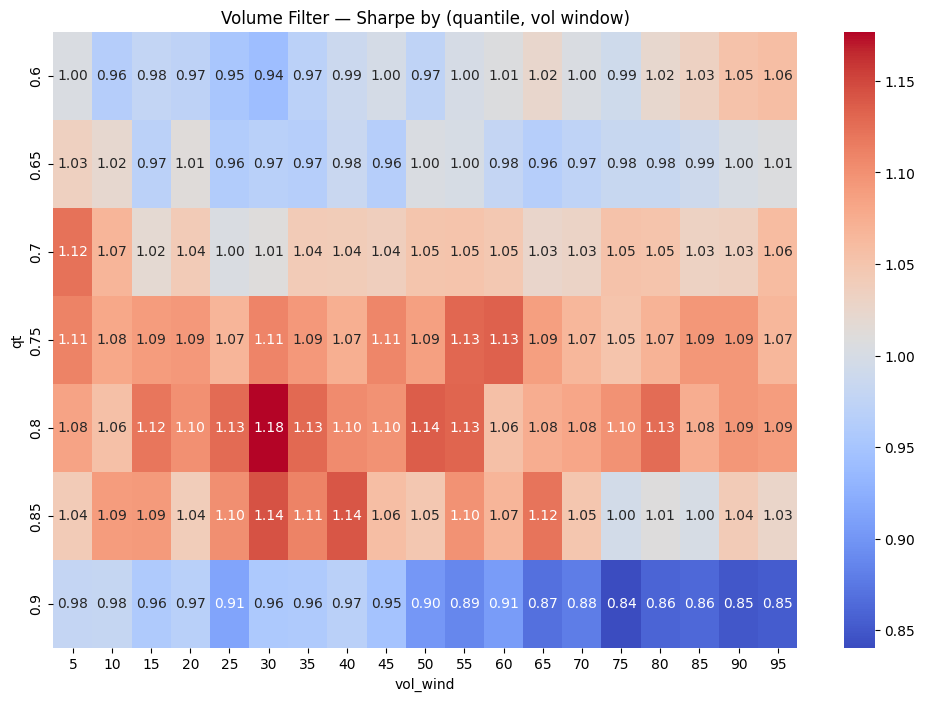

In [14]:
base_signal = -residuals_df.rolling(5).mean().shift(1)
base_signal = base_signal.sub(base_signal.mean(axis=1), axis=0)

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
ret_filtered = returns_df.where(liq_mask)

def run_vol_filter(params):
    sig = qs.volume_zscore_filter(
        base_signal,
        volume_df,
        window=params["vol_wind"],
        min_zscore_quantile=params["qt"],
    )
    sig = sig.where(liq_mask)
    pos = qs.build_positions(sig, n_long=25, n_short=25)
    return qs.run(pos, ret_filtered)

results = qs.param_grid(
    {"vol_wind": list(range(5, 100, 5)), "qt": [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]},
    run_vol_filter,
    metric_fn=qs.metrics.sharpe,
)

qs.param_heatmap(results, row_param="qt", col_param="vol_wind", metric="metric",
                  title="Volume Filter — Sharpe by (quantile, vol window)", figsize=(12, 8))

## Grid Search: Signal Window & Strength Quantile

param_grid: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:04<00:00,  6.71it/s]


<Axes: title={'center': 'Signal Strength Filter — Sharpe by (quantile, window)'}, xlabel='wind', ylabel='qt'>

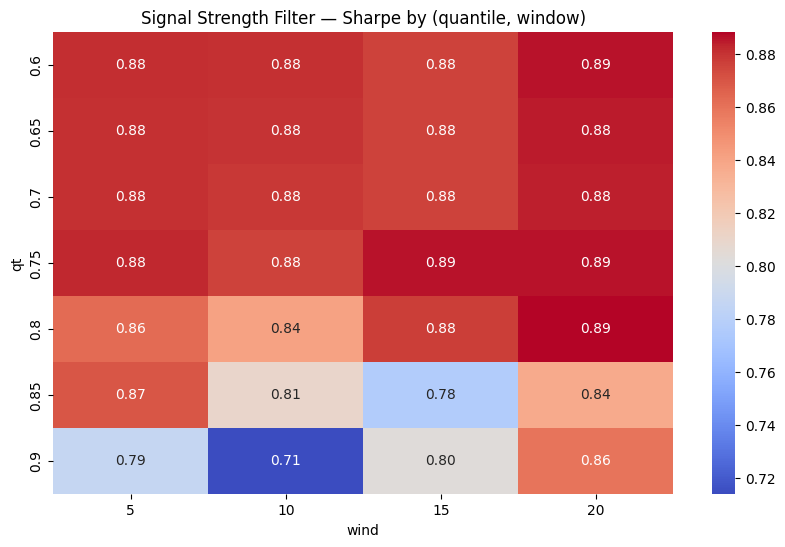

In [15]:
liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
ret_filtered = returns_df.where(liq_mask)

def run_signal_window(params):
    sig = -residuals_df.rolling(params["wind"]).mean().shift(1)
    sig = sig.sub(sig.mean(axis=1), axis=0)
    sig = sig.where(sig.abs().ge(sig.abs().quantile(params["qt"], axis=1), axis=0))
    sig = sig.where(liq_mask)
    pos = qs.build_positions(sig, n_long=25, n_short=25)
    return qs.run(pos, ret_filtered)

results = qs.param_grid(
    {"wind": [5, 10, 15, 20], "qt": [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]},
    run_signal_window,
    metric_fn=qs.metrics.sharpe,
)

qs.param_heatmap(results, row_param="qt", col_param="wind", metric="metric",
                  title="Signal Strength Filter — Sharpe by (quantile, window)")

## Grid Search: Residual Volatility Filter

param_grid: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 133/133 [00:17<00:00,  7.44it/s]


<Axes: title={'center': 'Residual Vol Filter — Sharpe by (quantile, vol window)'}, xlabel='vol_wind', ylabel='qt'>

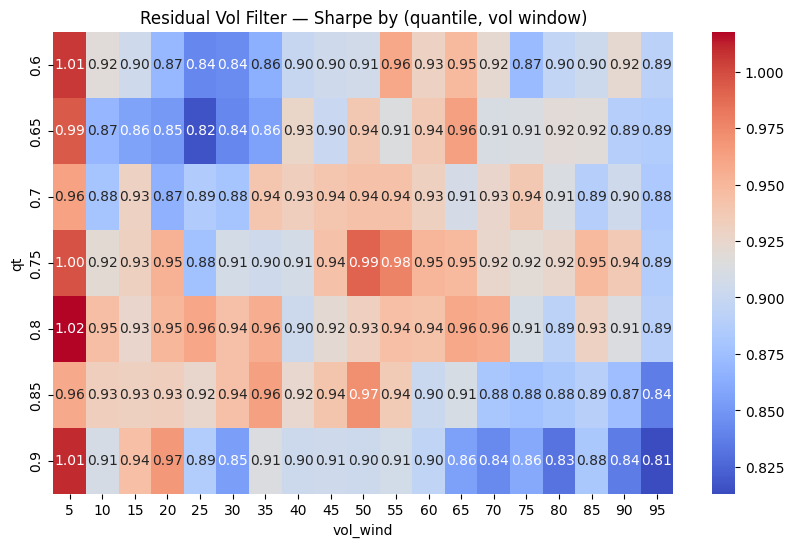

In [16]:
base_signal = -residuals_df.rolling(5).mean().shift(1)
base_signal = base_signal.sub(base_signal.mean(axis=1), axis=0)

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
ret_filtered = returns_df.where(liq_mask)

def run_vol_filter_resid(params):
    realized_vol = residuals_df.rolling(params["vol_wind"]).std()
    sig = base_signal.where(realized_vol.lt(realized_vol.quantile(params["qt"], axis=1), axis=0))
    sig = sig.where(liq_mask)
    pos = qs.build_positions(sig, n_long=25, n_short=25)
    return qs.run(pos, ret_filtered)

results = qs.param_grid(
    {"vol_wind": list(range(5, 100, 5)), "qt": [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]},
    run_vol_filter_resid,
    metric_fn=qs.metrics.sharpe,
)

qs.param_heatmap(results, row_param="qt", col_param="vol_wind", metric="metric",
                  title="Residual Vol Filter — Sharpe by (quantile, vol window)")

## Best Combo: Volume + Residual Vol Filters

sharpe                     1.029190
ann_return                 0.196055
ann_vol                    0.191954
max_drawdown              -0.342659
max_drawdown_duration    493.000000
avg_daily_turnover         1.418532
dtype: float64


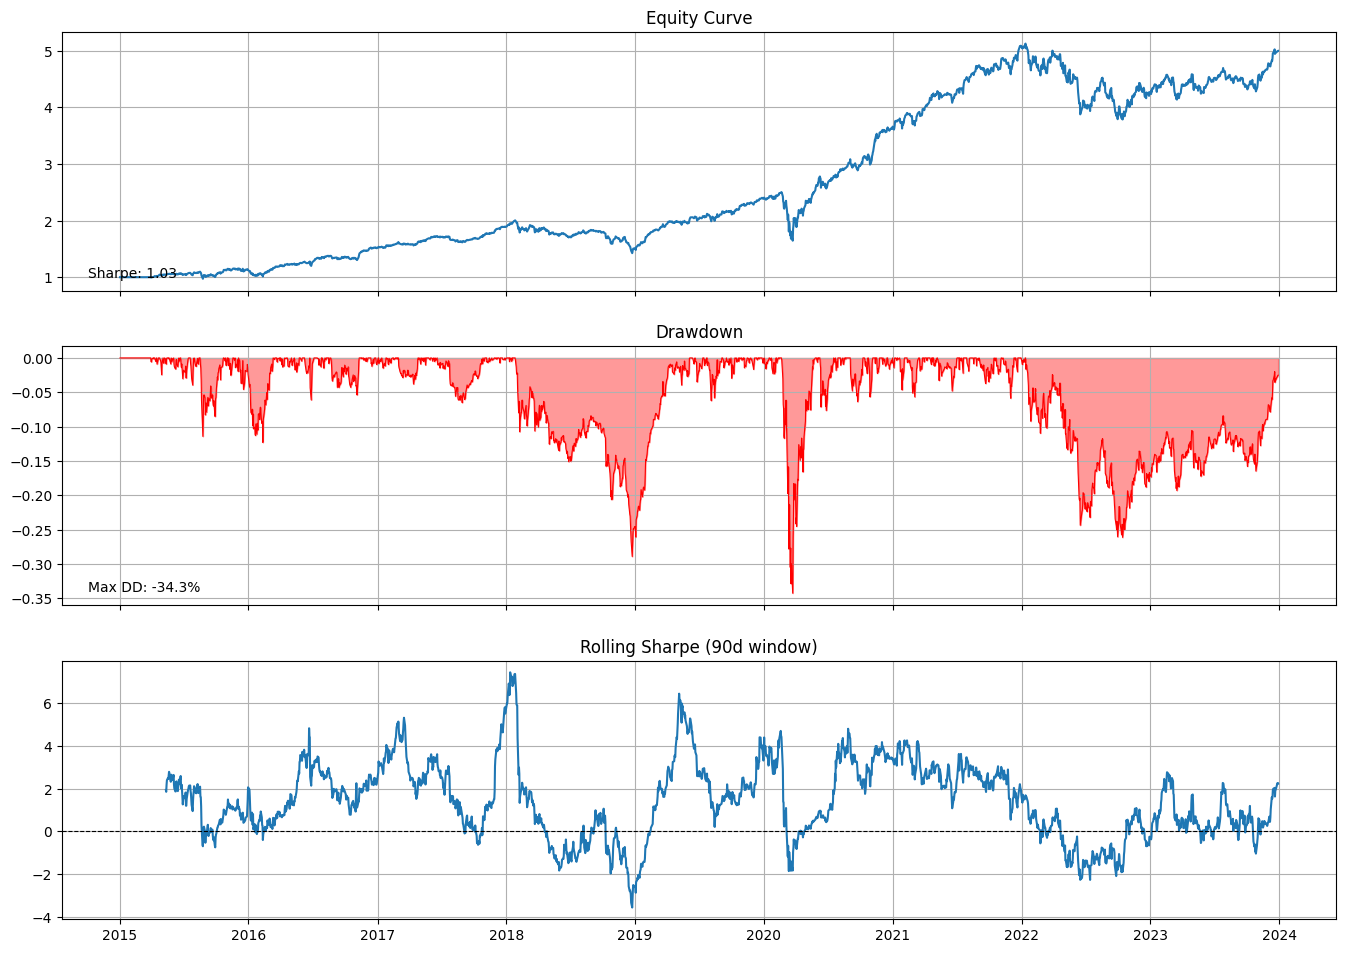

In [18]:
signal = -residuals_df.rolling(5).mean().shift(1)
signal = signal.sub(signal.mean(axis=1), axis=0)
signal = qs.vol_filter(signal, residuals_df, vol_window=5, quantile=0.6)
signal = qs.volume_zscore_filter(signal, volume_df, window=30, min_zscore_quantile=0.8)

liq_mask = qs.liquidity_filter(close_df, volume_df, top_n=250)
signal = signal.where(liq_mask)
ret_filtered = returns_df.where(liq_mask)

positions = qs.build_positions(signal, n_long=25, n_short=25)
port_ret = qs.run(positions, ret_filtered)

print(qs.metrics.summary(port_ret, positions))
ax = qs.summary_plot(port_ret)

In [ ]:
factor_returns